# Домашняя работа 3: Разработка модели детектирования объектов

##  Фоменко Елизавета Антоновна


На семинаре мы обсудили, разработали и попробовали `SSD` модель на базе `VGG16`, поэтому для успешного выполнения домашнего задания рекомендуется обратиться к семинару.

Задачи домашнего задания:
 - Загрузить набор данных и визуализировать объекты. (2 балла)
 - Разработать функцию для расчета метрики mAP задачи детектирования объектов. Продемонстрировать работу. (4 балла)
 - Натренировать `SSD` модель на базе VGG16. Продемонстрировать повышение метрики mAP (4 балла)
 - Разработать `SSD` модель согласно предлагаемой архитектуры на базе `ResNet18`. Продемонстрировать повышение метрики mAP (10 баллов)
 - (БОНУС) Добавить разнообразные аугментации изображений. Можно позаимствовать из других репозитариев с указанием источника. Повторить эксперименты (5 баллов)

## Описание предлагаемых исходных кодов и набора данных
- voc_dataset.py     - загружает предлагаемый набор данных, здесь также возможно выполнять аугментации над данными.
- voc_dataloader.py  - формирует порцию данных.
- prior_boxes.py     - содержит все необходимые функции для работы с `prior` боксами.
    - prior_boxes - функция генерирует `prior` боксы в соотвествии с конфигурацией
    - match       - функция решает задачу сопоставления `ground truth` боксов из набора данных и `prior` боксов
    - decode      - функция вычисляет поправки между `ground truth` боксами и `prior` боксами, собственно их будет *предсказывать* наша модель
    - encode      - функция пересчитывает `prior` боксы и *предсказанные* поправки в результирующие детектирования

- multibox_loss.py - комплексная функция потерь, решается задача сопоставления *предсказанных* и `ground truth` боксов, применяется техника `hard-negative mining`, вычисляется общая функция потерь.

In [ ]:
!git clone https://github.com/SergeyMalashenko/ObjectDetectionProblemFromScratch.git utils

Cloning into 'utils'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 20 (delta 6), reused 15 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 22.66 KiB | 2.52 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [ ]:
!gdown --id 14UheyBtIByVktCsOR7OF2gBsTNGAw26E
!tar -xzf dataset.tar.gz

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14UheyBtIByVktCsOR7OF2gBsTNGAw26E
From (redirected): https://drive.google.com/uc?id=14UheyBtIByVktCsOR7OF2gBsTNGAw26E&confirm=t&uuid=f6acae30-0ed8-4c9e-a1e8-440382cbb5b4
To: /content/dataset.tar.gz
100% 113M/113M [00:00<00:00, 333MB/s]


Набор данных состоит из `1528` изображений в разрешении `640x360` (тренировочная выборка - 1464 изображения, тестовая выборка - 64 изображения) в формате `VOC`.

Набор имеет следующую структуру:

|  Директория      | Содержимое |
| ---------------- | ---------- |
| Annotations      | папка содержит разметку в виде набора файлов в формате `XML`, каждый файл содержит информацию об объектах (класс объекта, рамка объекта `xmin,ymin,xmax,ymax`)    |
| ImageSets/Main   | папка содержит два текстовых файла с распределением данных на тренирововчную `trainval.txt` и тестовую выборки `test.txt` |
| JPEGImages       | папка содержит изображения в `JPEG` формате |

In [ ]:
import matplotlib.pyplot   as plt
import torch.nn.functional as F
import torchvision
import colorsys
import random
import torch
import cv2

from matplotlib.patches import Polygon
from matplotlib         import patches, lines
from torch              import nn
from PIL                import Image

import albumentations as alb
import numpy          as np
import scipy          as sp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install torchview

## Архитектура модели на основе VGG16

Обязательно посмотрите реализацию и разберитесь в том, как устроенна модель, это будет полезно при разработке собственной модели детектирования.

![Image](output_vgg16.png)

In [ ]:
# сначала сделаем модель SSD_VGG16 - я взяла ее с семинара

In [ ]:
from torchvision.models import VGG16_Weights                                # again - get weights for the original VGG16 model
from torchvision        import models
from torchview          import draw_graph

from torchvision.models import VGG16_Weights                                # for the backbone
from torchvision        import models

backbone_model    = models.vgg16(weights=VGG16_Weights.DEFAULT)             # for the backbone

backbone_model            # see initial VGG16 model structure

import torch.nn.init as init

class L2Norm(nn.Module):                                                    # add L2 layer
    def __init__(self, n_channels, scale):
        super(L2Norm, self).__init__()
        self.n_channels = n_channels
        self.gamma      = scale or None
        self.eps        = 1e-10
        self.weight     = nn.Parameter(torch.Tensor(self.n_channels))
        self.reset_parameters()

    def reset_parameters(self):
        init.constant_(self.weight, self.gamma)

    def forward(self, x):
        norm = torch.sqrt(x.pow(2).sum(dim=1, keepdim=True)) + self.eps
        x = torch.div(x, norm)
        x = self.weight.unsqueeze(0).unsqueeze(2).unsqueeze(3).expand_as(x) * x
        return x

class SSD_VGG16(nn.Module):                                                    # make our modek from layers we have already made
    def __init__(self, num_bboxes_s, num_labels = 3):
        super().__init__()

        self.num_bboxes_s = num_bboxes_s                                       # boxes per pixel?
        self.num_labels   = num_labels                                         # number of classes (with background)

        self.used_layer_id_s       = [21, 33, 37, 41, 45, 49]                  # layers with feature maps
        self.norm_layer            = L2Norm(512, 20)                           # L2 layer

        base_layers       = self._build_base_layers ()                           # base layers from VGG16
        extra_layers      = self._build_extra_layers()                           # extra layers (uax +)
        self.total_layers = base_layers + extra_layers                           # full model layers

        self.conf_layers, self.loc_layers = self._build_conf_loc_layers()        # conf + loc layers

    def _build_base_layers(self):                                                 # function to build our base (backbone layers)
        backbone_model    = models.vgg16(weights=VGG16_Weights.DEFAULT)           # start with normal VGG16 layers

        base_layers = nn.ModuleList(list(backbone_model.features)[:-1])          # everything we did before but made as class
        base_layers[16].ceil_mode = True

        pool5 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        conv6 = nn.Conv2d( 512, 1024, kernel_size=3, padding=6, dilation=6)
        relu6 = nn.ReLU(inplace=True)
        conv7 = nn.Conv2d(1024, 1024, kernel_size=1)
        relu7 = nn.ReLU(inplace=True)

        nn.init.xavier_uniform_(conv6.weight)
        nn.init.zeros_         (conv6  .bias)
        nn.init.xavier_uniform_(conv7.weight)
        nn.init.zeros_         (conv7  .bias)

        base_layers.extend( [pool5, conv6, relu6, conv7, relu7] )

        return base_layers

    def _build_extra_layers(self):
        extra_layers = []

        conv8_1  = nn.Conv2d( 1024, 256, kernel_size=1, stride=1           )
        relu8_1  = nn.ReLU(inplace=True)
        conv8_2  = nn.Conv2d( 256, 512, kernel_size=3, stride=2, padding=1)
        relu8_2  = nn.ReLU(inplace=True)
        conv9_1  = nn.Conv2d( 512, 128, kernel_size=1, stride=1           )
        relu9_1  = nn.ReLU(inplace=True)
        conv9_2  = nn.Conv2d( 128, 256, kernel_size=3, stride=2, padding=1)
        relu9_2  = nn.ReLU(inplace=True)
        conv10_1 = nn.Conv2d( 256, 128, kernel_size=1, stride=1           )
        relu10_1 = nn.ReLU(inplace=True)
        conv10_2 = nn.Conv2d( 128, 256, kernel_size=3, stride=1           )
        relu10_2 = nn.ReLU(inplace=True)
        conv11_1 = nn.Conv2d( 256, 128, kernel_size=1                     )
        relu11_1 = nn.ReLU(inplace=True)
        conv11_2 = nn.Conv2d( 128, 256, kernel_size=3, stride=1           )
        relu11_2 = nn.ReLU(inplace=True)

        nn.init.xavier_uniform_(conv8_1 .weight)
        nn.init.zeros_         (conv8_1 .bias  )
        nn.init.xavier_uniform_(conv8_2 .weight)
        nn.init.zeros_         (conv8_2 .bias  )
        nn.init.xavier_uniform_(conv9_1 .weight)
        nn.init.zeros_         (conv9_1 .bias  )
        nn.init.xavier_uniform_(conv9_2 .weight)
        nn.init.zeros_         (conv9_2 .bias  )
        nn.init.xavier_uniform_(conv10_1.weight)
        nn.init.zeros_         (conv10_1.bias  )
        nn.init.xavier_uniform_(conv10_2.weight)
        nn.init.zeros_         (conv10_2.bias  )
        nn.init.xavier_uniform_(conv11_1.weight)
        nn.init.zeros_         (conv11_1.bias  )
        nn.init.xavier_uniform_(conv11_2.weight)
        nn.init.zeros_         (conv11_2.bias  )

        extra_layers = nn.ModuleList( [conv8_1, relu8_1, conv8_2, relu8_2, conv9_1, relu9_1, conv9_2, relu9_2, conv10_1, relu10_1, conv10_2, relu10_2, conv11_1, relu11_1, conv11_2, relu11_2] )
        return extra_layers

    def _build_conf_loc_layers(self):
        out_channels_s = [ self.total_layers[i].out_channels for i in self.used_layer_id_s ]

        conf_layers, loc_layers = [], []
        for i, j in enumerate(self.used_layer_id_s):
            conf_layer = nn.Conv2d( self.total_layers[j].out_channels, self.num_bboxes_s[i] * self.num_labels, kernel_size=3, padding=1)
            loc_layer  = nn.Conv2d( self.total_layers[j].out_channels, self.num_bboxes_s[i] * 4              , kernel_size=3, padding=1)

            nn.init.xavier_uniform_(conf_layer.weight)
            nn.init.zeros_         (conf_layer  .bias)
            nn.init.xavier_uniform_(loc_layer .weight)
            nn.init.zeros_         (loc_layer   .bias)

            conf_layers += [conf_layer]
            loc_layers  += [loc_layer ]

        conf_layers = nn.ModuleList(conf_layers)
        loc_layers  = nn.ModuleList(loc_layers )

        return conf_layers, loc_layers

    def forward(self, x, verbose=False):
        source_s, loc_s, conf_s = [], [], []

        for i, current_layer in enumerate(self.total_layers, -1):
            x = current_layer(x)
            if i in self.used_layer_id_s:
                if i == 21:
                    s = self.norm_layer(x)
                else:
                    s = x
                source_s.append(s)
        for s, l, c in zip(source_s, self.loc_layers, self.conf_layers):
            conf_s.append(c(s).permute(0, 2, 3, 1).contiguous())
            loc_s .append(l(s).permute(0, 2, 3, 1).contiguous())
        conf_s = torch.cat([o.view(o.size(0), -1) for o in conf_s], 1)
        loc_s  = torch.cat([o.view(o.size(0), -1) for o in loc_s ], 1)

        conf_s = conf_s.view(conf_s.size(0), -1, self.num_labels)
        loc_s  = loc_s .view(loc_s .size(0), -1, 4              )

        return loc_s, conf_s

## Архитектура модели на основе ResNet18

Можно исследовать реализацию ResNet в пакете PyTorch, это будет полезно при разработке собственного детектора.

https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py

![Image](output_resnet18.png)

In [ ]:
# а здесь напишем аналогичный класс для VDD_ResNet18

In [ ]:
from torchvision        import models
from torchvision.models import ResNet18_Weights
from torchvision.models import VGG16_Weights

backbone_model    = models.resnet18(weights=ResNet18_Weights.DEFAULT)           # start with normal VGG16 layers

# base_layers = nn.ModuleList(list(backbone_model.features)[:-1])

base_layers = nn.Sequential(
    backbone_model.conv1,
    backbone_model.bn1,
    backbone_model.relu,
    backbone_model.maxpool,
    backbone_model.layer1,
    backbone_model.layer2,
    backbone_model.layer3,
    backbone_model.layer4
)

base_layers

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
# во-первых, нам надо поменять 7й блок (layer4 из оригинальной модели)

In [ ]:
# это официальный код ResNet из PyTorch. Я сделаю с помощью него новый layer4,
# который будет иметь 128 каналов на выходе (как в картинке модели)


import torch
import torch.nn as nn


def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=1, bias=False)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        norm_layer = nn.BatchNorm2d
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


def make_layer(inplanes, block, planes, blocks, stride=1):
    downsample = None
    if stride != 1 or inplanes != planes * block.expansion:
        downsample = nn.Sequential(
            conv1x1(inplanes, planes * block.expansion, stride),
            nn.BatchNorm2d(planes * block.expansion),
        )

    layers = []
    layers.append(block(inplanes, planes, stride, downsample))
    for _ in range(1, blocks):
        layers.append(block(planes * block.expansion, planes))
    return nn.Sequential(*layers)




def init_weights(resnet_layer):
    block0 = resnet_layer[0]
    block1 = resnet_layer[1]

    nn.init.xavier_uniform_(block0.conv1.weight)
    nn.init.xavier_uniform_(block1.conv1.weight)

    nn.init.xavier_uniform_(block0.conv2.weight)
    nn.init.xavier_uniform_(block1.conv2.weight)

    nn.init.xavier_uniform_(block0.downsample[0].weight)



In [ ]:
# теперь сделаем кастомный layer4

layer4_custom = make_layer(256, BasicBlock, 128, 2, stride=2)

# нужно еще сделать init weights для этого блока
init_weights(layer4_custom)

layer4_custom

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1

In [ ]:
# и заменим на него 7й блок в backbone модели

In [ ]:
base_layers = nn.Sequential(
    backbone_model.conv1,
    backbone_model.bn1,
    backbone_model.relu,
    backbone_model.maxpool,
    backbone_model.layer1,
    backbone_model.layer2,
    backbone_model.layer3,
    layer4_custom
)

base_layers

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
# теперь base_layers полностью совпадают с структурой с картинки
# первый feature map будет идти именно отсюад, размер 45x80, каналов на выходе 128

In [ ]:
# теперь делаем extrablocks

extra_layers = []                                                      # add aux layers (see paper) and init them


# second feature map, 23x40
conv5_1  = nn.Conv2d(128, 64, kernel_size=1, stride=1           )
relu5_1  = nn.ReLU(inplace=True)
conv5_2  = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
relu5_2  = nn.ReLU(inplace=True)


# third feature map, 12x20
conv6_1  = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
relu6_1  = nn.ReLU(inplace=True)
conv6_2  = nn.Conv2d( 64, 128, kernel_size=3, stride=2, padding=1)
relu6_2  = nn.ReLU(inplace=True)

# fourth feature map, 6x10
conv7_1 = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
relu7_1 = nn.ReLU(inplace=True)
conv7_2 = nn.Conv2d( 64, 128, kernel_size=3, stride=1           )
relu7_2 = nn.ReLU(inplace=True)

# fifth feature map, 3x5
conv8_1 = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
relu8_1 = nn.ReLU(inplace=True)
conv8_2 = nn.Conv2d( 64, 128, kernel_size=3, stride=1           )
relu8_2 = nn.ReLU(inplace=True)


# sixth feature map, 2x3
conv9_1 = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
relu9_1 = nn.ReLU(inplace=True)
conv9_2 = nn.Conv2d( 64, 128, kernel_size=3, stride=1           )
relu9_2 = nn.ReLU(inplace=True)


nn.init.xavier_uniform_(conv5_1 .weight)
nn.init.zeros_         (conv5_1 .bias  )
nn.init.xavier_uniform_(conv5_2 .weight)
nn.init.zeros_         (conv5_2 .bias  )

nn.init.xavier_uniform_(conv6_1 .weight)
nn.init.zeros_         (conv6_1 .bias  )
nn.init.xavier_uniform_(conv6_2 .weight)
nn.init.zeros_         (conv6_2 .bias  )

nn.init.xavier_uniform_(conv7_1.weight)
nn.init.zeros_         (conv7_1.bias  )
nn.init.xavier_uniform_(conv7_2.weight)
nn.init.zeros_         (conv7_2.bias  )

nn.init.xavier_uniform_(conv8_1.weight)
nn.init.zeros_         (conv8_1.bias  )
nn.init.xavier_uniform_(conv8_2.weight)
nn.init.zeros_         (conv8_2.bias  )

nn.init.xavier_uniform_(conv9_1.weight)
nn.init.zeros_         (conv9_1.bias  )
nn.init.xavier_uniform_(conv9_2.weight)
nn.init.zeros_         (conv9_2.bias  )

extra_layers = nn.Sequential(conv5_1, relu5_1, conv5_2, relu5_2,
                               conv6_1, relu6_1, conv6_2, relu6_2,
                               conv7_1, relu7_1, conv7_2, relu7_2,
                               conv8_1, relu8_1, conv8_2, relu8_2,
                               conv9_1, relu9_1, conv9_2, relu9_2)

In [ ]:
total_layers = base_layers + extra_layers
total_layers

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [ ]:
total_layers[7]

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(128, eps=1

In [ ]:
# теперб вспоминаем, откуда у нас идут feature maps-ы

used_layer_id_s       = [7, 10, 14, 18, 22, 26]  # feature maps layers ids from our model

# самый первый придется отдельно обрабатывать, потому что он не номерной :(

first_out_channel = [total_layers[used_layer_id_s[0]][1].conv2.out_channels]
others_out_channels = [ total_layers[used_layer_id_s[i]].out_channels for i in range(1, len(used_layer_id_s)) ]

out_channels_s = first_out_channel + others_out_channels

out_channels_s

[128, 128, 128, 128, 128, 128]

In [ ]:
num_bboxes_s = [2, 2, 2, 2, 2, 2]                                                 # ? number of boxes per pixel?
num_labels   = 2                                                                  # number of classes

conf_layers, loc_layers = [], []
for i, j in enumerate(used_layer_id_s):
    if i == 0:
        conf_layer = nn.Conv2d( total_layers[used_layer_id_s[0]][1].conv2.out_channels, num_bboxes_s[i] * num_labels, kernel_size=3, padding=1)
        loc_layer  = nn.Conv2d( total_layers[used_layer_id_s[0]][1].conv2.out_channels, num_bboxes_s[i] * 4         , kernel_size=3, padding=1)

    else:
        conf_layer = nn.Conv2d( total_layers[used_layer_id_s[i]].out_channels, num_bboxes_s[i] * num_labels, kernel_size=3, padding=1)
        loc_layer  = nn.Conv2d( total_layers[used_layer_id_s[i]].out_channels, num_bboxes_s[i] * 4         , kernel_size=3, padding=1)

    nn.init.xavier_uniform_(conf_layer.weight)
    nn.init.zeros_         (conf_layer  .bias)
    nn.init.xavier_uniform_(loc_layer .weight)
    nn.init.zeros_         (loc_layer   .bias)

    conf_layers += [conf_layer]
    loc_layers  += [loc_layer ]

    conf_layers = nn.ModuleList(conf_layers)
    loc_layers  = nn.ModuleList(loc_layers )

In [ ]:
# теперь, когда все работает, соберем все в один класс SSD_RESNET18

In [ ]:
from torchvision.models import VGG16_Weights                                # again - get weights for the original VGG16 model
from torchvision        import models
from torchview          import draw_graph


class SSD_RESNET18(nn.Module):                                                    # make our modek from layers we have already made
    def __init__(self, num_bboxes_s, num_labels = 3):
        super().__init__()

        self.num_bboxes_s = num_bboxes_s                                       # boxes per pixel?
        self.num_labels   = num_labels                                         # number of classes (with background)

        self.used_layer_id_s       = [7, 10, 14, 18, 22, 26]                  # layers with feature maps

        base_layers       = self._build_base_layers ()                           # base layers from VGG16
        extra_layers      = self._build_extra_layers()                           # extra layers (uax +)
        self.total_layers = base_layers + extra_layers                           # full model layers

        self.conf_layers, self.loc_layers = self._build_conf_loc_layers()        # conf + loc layers

    def _build_base_layers(self):

        # make custom layer4

        layer4_custom = make_layer(256, BasicBlock, 128, 2, stride=1)

        # нужно еще сделать init weights для этого блока
        init_weights(layer4_custom)

        # загружаем ResNet18 модель

        backbone_model    = models.resnet18(weights=ResNet18_Weights.DEFAULT)           # start with normal VGG16 layers

        # base_layers = nn.ModuleList(list(backbone_model.features)[:-1])

        base_layers = nn.Sequential(
            backbone_model.conv1,
            backbone_model.bn1,
            backbone_model.relu,
            backbone_model.maxpool,
            backbone_model.layer1,
            backbone_model.layer2,
            backbone_model.layer3,
            layer4_custom
            )

        return base_layers



    def _build_extra_layers(self):

        # теперь делаем extrablocks

        extra_layers = []                                                      # add aux layers (see paper) and init them


        # second feature map, 23x40
        conv5_1  = nn.Conv2d(128, 64, kernel_size=1, stride=1           )
        relu5_1  = nn.ReLU(inplace=True)
        conv5_2  = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        relu5_2  = nn.ReLU(inplace=True)


        # third feature map, 12x20
        conv6_1  = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
        relu6_1  = nn.ReLU(inplace=True)
        conv6_2  = nn.Conv2d( 64, 128, kernel_size=3, stride=2, padding=1)
        relu6_2  = nn.ReLU(inplace=True)

        # fourth feature map, 6x10
        conv7_1 = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
        relu7_1 = nn.ReLU(inplace=True)
        conv7_2 = nn.Conv2d( 64, 128, kernel_size=3, stride=2, padding=1)
        relu7_2 = nn.ReLU(inplace=True)

        # fifth feature map, 3x5
        conv8_1 = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
        relu8_1 = nn.ReLU(inplace=True)
        conv8_2 = nn.Conv2d( 64, 128, kernel_size=3, stride=2, padding=1)
        relu8_2 = nn.ReLU(inplace=True)


        # sixth feature map, 2x3
        conv9_1 = nn.Conv2d( 128, 64, kernel_size=1, stride=1           )
        relu9_1 = nn.ReLU(inplace=True)
        conv9_2 = nn.Conv2d( 64, 128, kernel_size=3, stride=2, padding=1)
        relu9_2 = nn.ReLU(inplace=True)


        nn.init.xavier_uniform_(conv5_1 .weight)
        nn.init.zeros_         (conv5_1 .bias  )
        nn.init.xavier_uniform_(conv5_2 .weight)
        nn.init.zeros_         (conv5_2 .bias  )

        nn.init.xavier_uniform_(conv6_1 .weight)
        nn.init.zeros_         (conv6_1 .bias  )
        nn.init.xavier_uniform_(conv6_2 .weight)
        nn.init.zeros_         (conv6_2 .bias  )

        nn.init.xavier_uniform_(conv7_1.weight)
        nn.init.zeros_         (conv7_1.bias  )
        nn.init.xavier_uniform_(conv7_2.weight)
        nn.init.zeros_         (conv7_2.bias  )

        nn.init.xavier_uniform_(conv8_1.weight)
        nn.init.zeros_         (conv8_1.bias  )
        nn.init.xavier_uniform_(conv8_2.weight)
        nn.init.zeros_         (conv8_2.bias  )

        nn.init.xavier_uniform_(conv9_1.weight)
        nn.init.zeros_         (conv9_1.bias  )
        nn.init.xavier_uniform_(conv9_2.weight)
        nn.init.zeros_         (conv9_2.bias  )

        extra_layers = nn.Sequential(conv5_1, relu5_1, conv5_2, relu5_2,
                               conv6_1, relu6_1, conv6_2, relu6_2,
                               conv7_1, relu7_1, conv7_2, relu7_2,
                               conv8_1, relu8_1, conv8_2, relu8_2,
                               conv9_1, relu9_1, conv9_2, relu9_2)

        return extra_layers




    def _build_conf_loc_layers(self):

        # самый первый придется отдельно обрабатывать, потому что он не номерной :(

        first_out_channel = [self.total_layers[used_layer_id_s[0]][1].conv2.out_channels]
        others_out_channels = [ self.total_layers[used_layer_id_s[i]].out_channels for i in range(1, len(self.used_layer_id_s)) ]

        out_channels_s = first_out_channel + others_out_channels


        conf_layers, loc_layers = [], []
        for i, j in enumerate(self.used_layer_id_s):
            if i == 0:
                conf_layer = nn.Conv2d( self.total_layers[self.used_layer_id_s[0]][1].conv2.out_channels, self.num_bboxes_s[i] * self.num_labels, kernel_size=3, padding=1)
                loc_layer  = nn.Conv2d( self.total_layers[self.used_layer_id_s[0]][1].conv2.out_channels, self.num_bboxes_s[i] * 4         , kernel_size=3, padding=1)

            else:
                conf_layer = nn.Conv2d( self.total_layers[self.used_layer_id_s[i]].out_channels, self.num_bboxes_s[i] * self.num_labels, kernel_size=3, padding=1)
                loc_layer  = nn.Conv2d( self.total_layers[self.used_layer_id_s[i]].out_channels, self.num_bboxes_s[i] * 4         , kernel_size=3, padding=1)

            nn.init.xavier_uniform_(conf_layer.weight)
            nn.init.zeros_         (conf_layer  .bias)
            nn.init.xavier_uniform_(loc_layer .weight)
            nn.init.zeros_         (loc_layer   .bias)

            conf_layers += [conf_layer]
            loc_layers  += [loc_layer ]

            conf_layers = nn.ModuleList(conf_layers)
            loc_layers  = nn.ModuleList(loc_layers )

        return conf_layers, loc_layers

    def forward(self, x, verbose=False):
        source_s, loc_s, conf_s = [], [], []

        for i, current_layer in enumerate(self.total_layers):
            x = current_layer(x)
            if i in self.used_layer_id_s:
                s = x
                source_s.append(s)

        for s, l, c in zip(source_s, self.loc_layers, self.conf_layers):
            conf_s.append(c(s).permute(0, 2, 3, 1).contiguous())
            loc_s .append(l(s).permute(0, 2, 3, 1).contiguous())
        conf_s = torch.cat([o.view(o.size(0), -1) for o in conf_s], 1)
        loc_s  = torch.cat([o.view(o.size(0), -1) for o in loc_s ], 1)

        conf_s = conf_s.view(conf_s.size(0), -1, self.num_labels)
        loc_s  = loc_s .view(loc_s .size(0), -1, 4              )

        return loc_s, conf_s

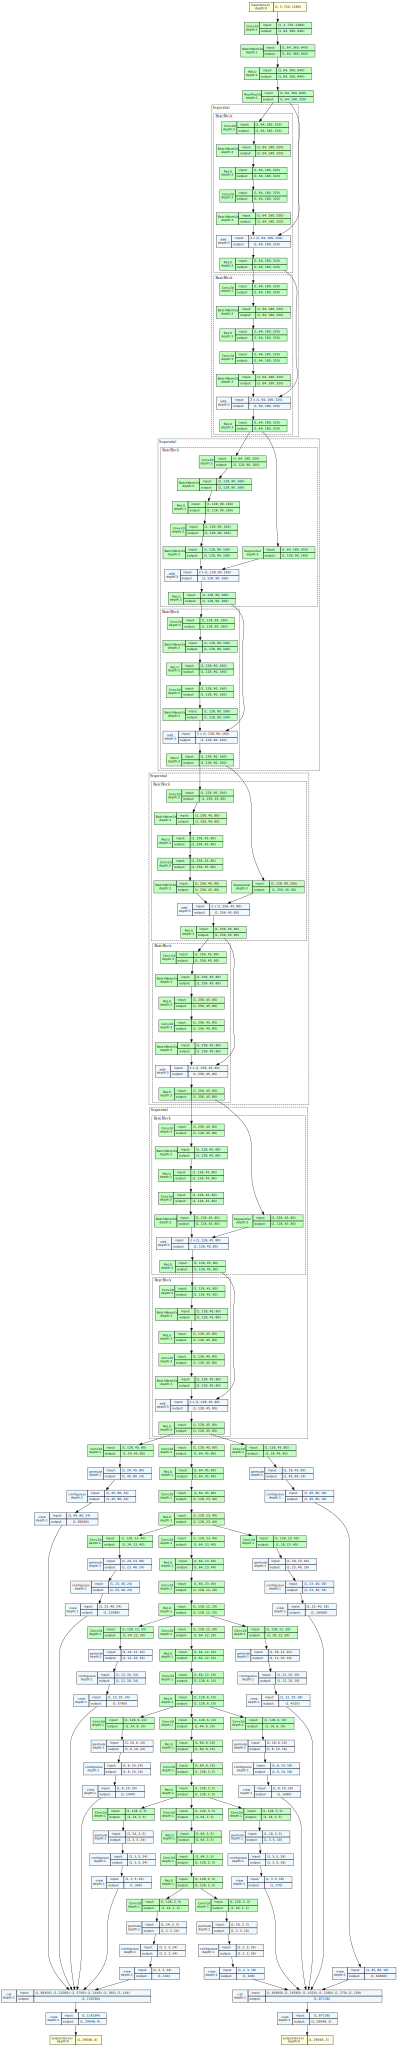

In [ ]:
# проверим собранную модель...

num_bboxes_s = [6, 6, 6, 6, 6, 6]

model = SSD_RESNET18(num_bboxes_s, 3)
model.eval()

input_data  = torch.randn(1,3,720, 1280, dtype=torch.float, requires_grad=False)
output_locs, output_confs = model( input_data )

model_graph  = draw_graph(model, input_size=(1,3,720,1280), expand_nested=True)
visual_graph = model_graph.visual_graph
visual_graph

In [ ]:
# УРА!!!! теперь у нас есть рабочая SSD_RESNET18 модель - такая же, как висит в картинке в домашке :)

In [ ]:
visual_graph.render(filename="ssd_resnet18_graph", format="png", cleanup=True)

'ssd_resnet18_graph.png'

## Создаем конфигурацию, которая описывает работы нашего детектора (пример для VGG16)

In [ ]:
# предсказываем для 3 классов - ('background','license_plate','car')

In [ ]:
#VGG16 - 640x360
custom_config_VGG16 = {
 'num_classes'  : 3,
 'feature_maps' : [(45,80), (22,40), (11,20), (6,10), (4,8), (2,6)], #VGG16 - 640x360, размерность карт признаков, которые будут использоваться
 'min_sizes'    : [0.10, 0.20, 0.37, 0.54, 0.71, 1.00], #Параметр масштаба боксов
 'max_sizes'    : [0.20, 0.37, 0.54, 0.71, 1.00, 1.05], #Параметр масштаба боксов

 'aspect_ratios': [[2, 3], [2, 3], [2, 3], [2, 3], [2], [2]], #Список содержаший информацию о соотношении сторон для prior боксов
 'num_priors'   : [6, 6, 6, 6, 4, 4], #Число prior боксов
 'variance'     : [0.1, 0.2],
 'clip'         :    True,

 'overlap_threshold': 0.5, #Параметр IoU
 'neg_pos_ratio'    :   3, #Параметр hard-negative mining

 'model_name' : 'vgg16'
}


In [ ]:
#ResNet - 1280x720
custom_config_ResNet18 = {
 'num_classes'  : 3,
 'feature_maps' : [(45,80), (23,40), (12,20), (6,10), (3,5), (2,3)], #ResNet - 1280x720, размерность карт признаков, которые будут использоваться
 'min_sizes'    : [0.10, 0.20, 0.37, 0.54, 0.71, 1.00], #Параметр масштаба боксов
 'max_sizes'    : [0.20, 0.37, 0.54, 0.71, 1.00, 1.05], #Параметр масштаба боксов

 'aspect_ratios': [[2, 3], [2, 3], [2, 3], [2, 3], [2, 3], [2, 3]], # чтобы модель была как требуется
 'num_priors'   : [6, 6, 6, 6, 6, 6],                               # чтобы модель была как требуется
 'variance'     : [0.1, 0.2],
 'clip'         :    True,

 'overlap_threshold': 0.5, #Параметр IoU
 'neg_pos_ratio'    :   3, #Параметр hard-negative mining

 'model_name' : 'resnet18'
}


## Загружаем требуемый набор данных

In [ ]:
!gdown --id 14UheyBtIByVktCsOR7OF2gBsTNGAw26E
!tar -xzf dataset.tar.gz

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=14UheyBtIByVktCsOR7OF2gBsTNGAw26E
From (redirected): https://drive.google.com/uc?id=14UheyBtIByVktCsOR7OF2gBsTNGAw26E&confirm=t&uuid=abf74991-0c61-417f-a6bd-a0a154408f27
To: /content/dataset.tar.gz
100% 113M/113M [00:02<00:00, 52.4MB/s]


In [ ]:
# визуализируем несколько картинок.

In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

import random
import glob

test_image_s = random.sample( glob.glob("dataset/JPEGImages/*.jpg"), 9 )


fig, ax = plt.subplots(nrows=3, ncols=3, gridspec_kw = {'wspace':0, 'hspace':0}, figsize=(300, 200))

for index, image_filename in enumerate(test_image_s):
    i = index // 3
    j = index % 3

    source_image_numpy = cv2.imread(image_filename)
    source_image_numpy = np.transpose(source_image_numpy.astype(np.float32) / 255., axes=[2,0,1])
    target_image_cpu   = torch.from_numpy(source_image_numpy * 255).to(torch.uint8)
    target_image_numpy = target_image_cpu.permute([1,2,0]).numpy()

    ax[i][j].imshow(target_image_numpy )
    ax[i][j].axis('off')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# отлично, теперь знаем, что имеем дело с машинами на заправке, ищем машину + номер

## Разработать функцию вычисление mAP метрики задачи детектирования

В качестве примера можно использовать https://lightning.ai/docs/torchmetrics/stable/detection/mean_average_precision.html

In [ ]:
from argparse import Namespace

param_s = Namespace(
 dataset_root_dir='dataset',
 epochs = 15, batch_size = 4,
 checkpoint = None, output = 'output',
 multistep = [20, 30, 40],
 learning_rate = 1e-3, momentum = 0.9,
 weight_decay = 0.0005, warmup = None,
 num_workers = 1,
 seed = 42
)

In [ ]:
import sys
#Добавляем директорию, чтобы была возможность импортировать необходимые модули
sys.path.insert(0, 'utils')

from torch.optim.lr_scheduler import MultiStepLR
from utils.voc_dataloader     import get_train_dataloader, get_test_dataloader
from utils.prior_boxes        import detect_objects, prior_boxes

from tqdm        import tqdm

import time
import os

In [ ]:
from utils.voc_dataloader import get_train_dataloader, get_test_dataloader

dataset_root_dir          = 'dataset'
test_annotation_filename  = os.path.join( dataset_root_dir, "ImageSets/Main/test.txt"     )
train_annotation_filename = os.path.join( dataset_root_dir, "ImageSets/Main/trainval.txt" )
train_dataloader          = get_train_dataloader(dataset_root_dir, train_annotation_filename, param_s.batch_size, param_s.num_workers)
test_dataloader           = get_test_dataloader (dataset_root_dir, test_annotation_filename , param_s.batch_size, param_s.num_workers)

In [ ]:
# теперь пишем mAP функцию. пусть на выход она получает выходы нашей модели и ground_true

class mAP: # PyTorch manner - with dictionaries
    def __init__(self, args, cfg, iou_thr = 0.5, conf_thr = 0.1, eps = 1e-8):

        self.cfg = cfg
        self.args = args

        self.cnts = 0

        self.iou_thr = iou_thr
        self.conf_thr = conf_thr
        self.eps = eps

        self.predictions = []
        self.targets = []

        # first compute real boxes bounds, clasees and confs using utils help functions



    def update(self, pred_loc_ss_gpu, pred_conf_ss_gpu, true_labels, true_boxs, prior_box_s): # add images from a batch!

        # first compute real boxes bounds, clasees and confs using utils help functions
        target_box_ss, target_label_ss, target_conf_ss = detect_objects(pred_loc_ss_gpu, pred_conf_ss_gpu, prior_box_s, self.cfg['num_classes'], self.iou_thr, self.conf_thr)

        for i in range(self.args.batch_size):
            pred_boxes = target_box_ss[i]
            pred_labels = target_label_ss[i]
            pred_scores = target_conf_ss[i]
            gt_boxes = true_boxs[i]
            gt_labels = true_labels[i]

            # Add predictions
            for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
                self.predictions.append({
                    "image_id": self.cnts,
                    "class": int(label),
                    "score": float(score),
                    "box": box.cpu()
                })

            # Add ground truths
            for box, label in zip(gt_boxes, gt_labels):
                self.targets.append({
                    "image_id": self.cnts,
                    "class": int(label),
                    "box": box.cpu()
                })

            self.cnts += 1


    def get_IOU(self, target_box_ss, true_boxes): # per object functionm cause every image has its own number of boxes :(

        target_box_ss = target_box_ss.unsqueeze(1)
        true_boxes   = true_boxes.unsqueeze(0)

        xi_min = torch.max(target_box_ss[:, :, 0],true_boxes[:, :, 0])    # max of x_mins
        yi_min = torch.max(target_box_ss[:, :, 1],true_boxes[:, :, 1])    # max of y_mins
        xi_max = torch.min(target_box_ss[:, :, 2],true_boxes[:, :, 2])    # min of x_maxs
        yi_max = torch.min(target_box_ss[:, :, 3],true_boxes[:, :, 3])    # min of y_maxs

        inter_area = torch.max(torch.zeros(size = (xi_min.shape)), xi_max - xi_min) * torch.max(torch.zeros(size = (yi_min.shape)), yi_max - yi_min)

        box1_area = (target_box_ss[:, :, 2] - target_box_ss[:, :, 0]) * (target_box_ss[:, :, 3] - target_box_ss[:, :, 1])
        box2_area = (true_boxes[:, :, 2] - true_boxes[:, :, 0]) * (true_boxes[:, :, 3] - true_boxes[:, :, 1])

        union_area = box1_area + box2_area - inter_area

        return inter_area / (union_area + self.eps)          # returns a tensor of (size num_pred x num_true), added eps for stability


    def compute(self):
        APs_per_class = []
        classes = sorted(set([g["class"] for g in self.targets]))

        for cls in classes:
            preds = [p for p in self.predictions if p["class"] == cls]
            trues = [g for g in self.targets if g["class"] == cls]

            # Count truths per image
            gt_count_per_image = {}
            for g in trues:
                gt_count_per_image.setdefault(g["image_id"], 0)
                gt_count_per_image[g["image_id"]] += 1

            preds = sorted(preds, key=lambda x: x["score"], reverse=True)

            tp = torch.zeros(len(preds))
            fp = torch.zeros(len(preds))
            matched = {img_id: torch.zeros(count) for img_id, count in gt_count_per_image.items()}

            for i, pred in enumerate(preds):
                gt_for_image = [g for g in trues if g["image_id"] == pred["image_id"]]

                if len(gt_for_image) == 0:
                    fp[i] = 1
                    continue

                gt_boxes = torch.stack([g["box"] for g in gt_for_image])
                ious = self.get_IOU(pred["box"].unsqueeze(0), gt_boxes)[0]
                best_iou, best_idx = ious.max(0)

                if best_iou >= self.iou_thr and matched[pred["image_id"]][best_idx] == 0:
                    tp[i] = 1
                    matched[pred["image_id"]][best_idx] = 1
                else:
                    fp[i] = 1

            # Compute precision-recall
            tp_cum = torch.cumsum(tp, dim=0)
            fp_cum = torch.cumsum(fp, dim=0)
            recall = tp_cum / (len(trues) + 1e-6)
            precision = tp_cum / (tp_cum + fp_cum + 1e-6)

            # 11-point interpolation for AP
            recall_levels = torch.linspace(0, 1, 11)
            precisions_interp = []
            for r in recall_levels:
                precisions_interp.append(precision[recall >= r].max() if (recall >= r).any() else 0.0)
            ap = torch.tensor(precisions_interp).mean().item()
            APs_per_class.append(ap)

        mean_ap = sum(APs_per_class) / len(APs_per_class) if APs_per_class else 0.0
        return {"mAP": mean_ap, "AP_per_class": {cls: ap for cls, ap in zip(classes, APs_per_class)}}



## пишем train_step

In [ ]:
import sys
#Добавляем директорию, чтобы была возможность импортировать необходимые модули
sys.path.insert(0, 'utils')

from torch.optim.lr_scheduler import MultiStepLR
from utils.voc_dataloader     import get_train_dataloader, get_test_dataloader
from utils.prior_boxes        import detect_objects, prior_boxes
from utils.multibox_loss      import MultiBoxLoss

from tqdm        import tqdm

import time
import os



def train_process(args, custom_config):

    resize_pic_360_640 = torchvision.transforms.Resize((360, 640))           # use in with vgg16 model as it takes 360x480 pictures
    resize_pic_720_1280 = torchvision.transforms.Resize((720, 1280))           # use in with vgg16 model as it takes 360x480 pictures

    torch.manual_seed(     args.seed)
    np.random.seed   (seed=args.seed)

    dataset_root_dir          = args.dataset_root_dir
    train_annotation_filename = os.path.join( dataset_root_dir, "ImageSets/Main/trainval.txt" )
    test_annotation_filename  = os.path.join( dataset_root_dir, "ImageSets/Main/test.txt"     )
    train_dataloader          = get_train_dataloader(dataset_root_dir, train_annotation_filename, args.batch_size, args.num_workers)
    test_dataloader           = get_test_dataloader (dataset_root_dir, test_annotation_filename , args.batch_size, args.num_workers)

    learning_rate = args.learning_rate

    mAPs = []

    if not os.path.exists(args.output):
        os.mkdir(args.output)


    # load model (ssd_vgg16 or ssd_resnet18)

    if custom_config['model_name'][:3] == 'vgg':
        model = SSD_VGG16(custom_config['num_priors'], custom_config['num_classes'])
    else:
        model = SSD_RESNET18(custom_config['num_priors'], custom_config['num_classes'])


    prior_box_s = prior_boxes(custom_config)
    prior_box_s_gpu = prior_box_s.cuda()


    overlap_threshold = custom_config['overlap_threshold']
    neg_pos_ratio     = custom_config['neg_pos_ratio'    ]
    variance          = custom_config['variance']

    criterion = MultiBoxLoss( overlap_threshold, neg_pos_ratio, variance)
    model    .cuda()
    criterion.cuda()

    optimizer = torch.optim.SGD(model.parameters(), lr=args.learning_rate, momentum=args.momentum, weight_decay=args.weight_decay )
    scheduler = MultiStepLR(optimizer=optimizer, milestones=args.multistep, gamma=0.2)

    best_loc_loss, best_cls_loss, best_loss = np.inf, np.inf, np.inf
    train_loss_s, eval_loss_s = [], []


    for epoch in tqdm(list(range(args.epochs))):

        #Train model
        train_loc_loss, train_cls_loss, train_loss = 0, 0, 0
        model.train()
        for i , (image_s_cpu, box_ss_cpu, label_ss_cpu) in enumerate(train_dataloader):          # gives a batch of images
            if len(box_ss_cpu) > 0 and len(label_ss_cpu) > 0:
                image_s_gpu  =   image_s_cpu.cuda()

                if custom_config['model_name'][:3] == 'vgg':                         # resize images for vgg16
                    image_s_gpu = resize_pic_360_640(image_s_gpu)
                else:
                    image_s_gpu = resize_pic_720_1280(image_s_gpu)

                label_ss_gpu = [ label_s_cpu.cuda() for label_s_cpu in label_ss_cpu ]
                box_ss_gpu   = [ box_s_cpu  .cuda() for box_s_cpu   in box_ss_cpu   ]

                pred_loc_ss_gpu, pred_conf_ss_gpu = model(image_s_gpu)
                loc_loss, cls_loss = criterion( (pred_loc_ss_gpu, pred_conf_ss_gpu, prior_box_s_gpu), (label_ss_gpu, box_ss_gpu))

                loss = loc_loss + cls_loss

                optimizer.zero_grad()
                loss     .backward ()
                optimizer.step     ()

                train_loc_loss += loc_loss.item()
                train_cls_loss += cls_loss.item()
                train_loss     += loss    .item()


        scheduler.step()
        train_loss_s.append(train_loss)



        #Eval model
        eval_loc_loss, eval_cls_loss, eval_loss = 0, 0, 0
        model.eval()

        with torch.no_grad():
            mymap = mAP(param_s, custom_config_ResNet18)

            for i , (image_s_cpu, box_ss_cpu, label_ss_cpu) in enumerate(test_dataloader):
                if len(box_ss_cpu) > 0 and len(label_ss_cpu) > 0:
                    image_s_gpu = image_s_cpu.cuda()

                    if custom_config['model_name'][:3] == 'vgg':                         # resize images for vgg16
                        image_s_gpu = resize_pic_360_640(image_s_gpu)
                    else:
                        image_s_gpu = resize_pic_720_1280(image_s_gpu)

                    label_ss_gpu = [ label_s_cpu.cuda() for label_s_cpu in label_ss_cpu ]
                    box_ss_gpu   = [ box_s_cpu  .cuda() for box_s_cpu   in box_ss_cpu   ]

                    pred_loc_ss_gpu, pred_conf_ss_gpu = model(image_s_gpu)

                    loc_loss, cls_loss = criterion( (pred_loc_ss_gpu, pred_conf_ss_gpu, prior_box_s_gpu), (label_ss_gpu, box_ss_gpu))
                    loss = loc_loss + cls_loss

                    eval_loc_loss += loc_loss.item()
                    eval_cls_loss += cls_loss.item()
                    eval_loss     += loss    .item()

                    pred_loc_ss_cpu = pred_loc_ss_gpu.cpu()
                    pred_conf_ss_cpu = pred_conf_ss_gpu.cpu()

                    mymap.update(pred_loc_ss_gpu, pred_conf_ss_gpu, label_ss_gpu, box_ss_gpu, prior_box_s_gpu)

        epoch_mAP =  mymap.compute()
        mAPs.append(epoch_mAP)
        eval_loss_s.append(eval_loss)

        print('epoch[{}] | lr {:.5f} | loc_loss [{:.3f}/{:.3f}] | cls_loss [{:.3f}/{:.3f}] | total_loss [{:.3f}/{:.3f}] | mAP {:.3f}'.format(epoch, scheduler.get_last_lr()[0], train_loc_loss, eval_loc_loss, train_cls_loss, eval_cls_loss, train_loss, eval_loss, epoch_mAP['mAP']))

        if eval_loss < best_loss :
            torch.save(model.state_dict(), os.path.join(args.output, f"{custom_config['model_name']}.pth"))
            best_loc_loss, best_cls_loss, best_loss = eval_loc_loss, eval_cls_loss, eval_loss

    return model, prior_box_s, train_loss_s, eval_loss_s, mAPs

## Натренировать модель на основе VGG16

## Натренировать модель на основе ResNet18

In [ ]:
model_resnet18, prior_box_s_resnet18, train_loss_s_resnet18, eval_loss_s_resnet18, mAPs_resnet18 = train_process(param_s, custom_config_ResNet18) # lr 1e-3

  5%|▌         | 1/20 [01:52<35:34, 112.33s/it]

epoch[0] | lr 0.00100 | loc_loss [651.797/19.015] | cls_loss [1060.308/31.898] | total_loss [1712.105/50.913] | mAP 0.157


 10%|█         | 2/20 [03:40<33:00, 110.00s/it]

epoch[1] | lr 0.00100 | loc_loss [349.848/11.981] | cls_loss [650.496/26.451] | total_loss [1000.345/38.432] | mAP 0.449


 15%|█▌        | 3/20 [05:32<31:22, 110.76s/it]

...

epoch[17] | lr 0.00100 | loc_loss [106.596/5.073] | cls_loss [366.833/17.993] | total_loss [473.428/23.067] | mAP 0.785


 95%|█████████▌| 19/20 [33:54<01:42, 102.97s/it]

epoch[18] | lr 0.00100 | loc_loss [102.457/5.382] | cls_loss [361.448/18.683] | total_loss [463.905/24.066] | mAP 0.816


100%|██████████| 20/20 [35:37<00:00, 106.87s/it]

epoch[19] | lr 0.00020 | loc_loss [100.076/4.631] | cls_loss [354.343/17.941] | total_loss [454.419/22.572] | mAP 0.784


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



def graphics(mAPs, train_loss_s, eval_loss_s, name, epoch_num = 20):
    fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 10))

    plt.suptitle(name, size = 20)

    axes[0, 0].plot(np.arange(epoch_num), train_loss_s, color='orange', label = 'train_loss')
    axes[0, 0].plot(np.arange(epoch_num), eval_loss_s, color='green', label = 'eval_loss')
    axes[0, 0].set_title('Total loss', fontsize=15, loc = 'left')
    axes[0, 0].tick_params(axis='both', labelsize=11)
    axes[0, 0].legend(fontsize=12)
    axes[0, 0].get_legend().remove()
    axes[0, 0].set_xlabel('epoch', size = 14)
    axes[0, 0].set_ylabel('loss', size = 14)

    axes[0, 1].plot(np.arange(epoch_num), np.array(train_loss_s) / 1464, color='orange', label = 'train_loss')
    axes[0, 1].plot(np.arange(epoch_num), np.array(eval_loss_s) / 64, color='green', label = 'eval_loss')
    axes[0, 1].set_title('Mean loss', fontsize=15, loc = 'left')
    axes[0, 1].tick_params(axis='both', labelsize=11)
    axes[0, 1].legend(fontsize=12)
    axes[0, 1].set_xlabel('epoch', size = 14)
    axes[0, 1].set_ylabel('loss', size = 14)

    mAP = [x['mAP'] for x in mAPs]
    class1_APs = [x['AP_per_class'][1] for x in mAPs]
    class2_APs = [x['AP_per_class'][2] for x in mAPs]

    axes[1, 0].plot(np.arange(epoch_num), mAP, color='red')
    axes[1, 0].set_title('Mean Average Precision (mAP)', fontsize=15, loc = 'left')
    axes[1, 0].tick_params(axis='both', labelsize=11)
    axes[1, 0].legend(fontsize=12)
    axes[1, 0].get_legend().remove()
    axes[1, 0].set_xlabel('epoch', size = 14)
    axes[1, 0].set_ylabel('mAP', size = 14)

    axes[1, 1].plot(np.arange(epoch_num), class1_APs, color='blue', label = 'license_plate')
    axes[1, 1].plot(np.arange(epoch_num), class2_APs, color='pink', label = 'car')
    axes[1, 1].set_title('Average Precision per class', fontsize=15, loc = 'left')
    axes[1, 1].tick_params(axis='both', labelsize=11)
    axes[1, 1].legend(fontsize=12)
    axes[1, 1].set_xlabel('epoch', size = 14)
    axes[1, 1].set_ylabel('AP', size = 14)

    plt.show()


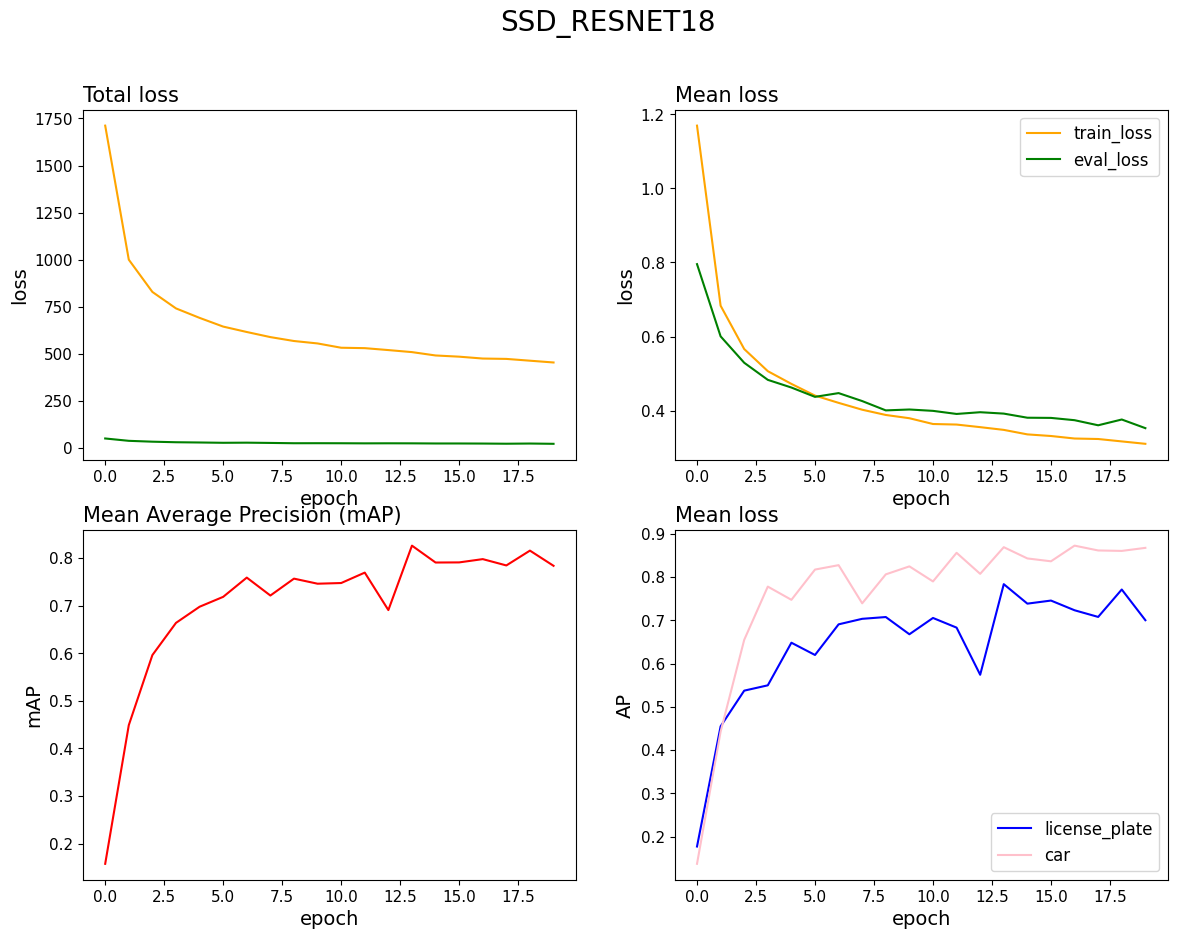

In [ ]:
graphics(mAPs_resnet18, train_loss_s_resnet18, eval_loss_s_resnet18, 'SSD_RESNET18')  # lr 1e-3

In [ ]:
# colab умеет вовремя вылетать, поэтому тут сохраню на всякий случай все данные результаты

"""
train_loss_s_resnet18 =
[1712.1045308113098,
 1000.3447197675705,
 829.0410549640656,
 741.5759190320969,
 691.2917175292969,
 645.0243148803711,
 616.289275765419,
 589.2008212208748,
 568.4317988753319,
 555.5439926981926,
 532.7168574929237,
 530.5374734997749,
 520.2979612350464,
 509.4888985157013,
 491.67648696899414,
 485.2885237932205,
 475.3355258703232,
 473.4284687638283,
 463.9045135974884,
 454.41942793130875]


eval_loss_s_resnet18 =
[50.91269898414612,
 38.431846022605896,
 33.87097120285034,
 30.917582869529724,
 29.5892516374588,
 27.979114055633545,
 28.62882936000824,
 27.25152051448822,
 25.64044564962387,
 25.795198559761047,
 25.559522211551666,
 25.02606338262558,
 25.32462340593338,
 25.085353016853333,
 24.37383484840393,
 24.343112885951996,
 23.946336686611176,
 23.06656676530838,
 24.065614342689514,
 22.572206139564514]

 mAPs_resnet18 =
 [{'mAP': 0.1574924886226654,
  'AP_per_class': {1: 0.17747649550437927, 2: 0.13750848174095154}},
 {'mAP': 0.44893573224544525,
  'AP_per_class': {1: 0.4550809860229492, 2: 0.4427904784679413}},
 {'mAP': 0.5962271094322205,
  'AP_per_class': {1: 0.5375528931617737, 2: 0.6549013257026672}},
 {'mAP': 0.6638997495174408,
  'AP_per_class': {1: 0.5498537421226501, 2: 0.7779457569122314}},
 {'mAP': 0.697827160358429,
  'AP_per_class': {1: 0.6482800245285034, 2: 0.7473742961883545}},
 {'mAP': 0.7186205685138702,
  'AP_per_class': {1: 0.6199660301208496, 2: 0.8172751069068909}},
 {'mAP': 0.759088397026062,
  'AP_per_class': {1: 0.6907258629798889, 2: 0.8274509310722351}},
 {'mAP': 0.7213932871818542,
  'AP_per_class': {1: 0.7034983038902283, 2: 0.7392882704734802}},
 {'mAP': 0.7569078803062439,
  'AP_per_class': {1: 0.7076132893562317, 2: 0.8062024712562561}},
 {'mAP': 0.7462417185306549,
  'AP_per_class': {1: 0.6678282618522644, 2: 0.8246551752090454}},
 {'mAP': 0.7476639151573181,
  'AP_per_class': {1: 0.7054854035377502, 2: 0.789842426776886}},
 {'mAP': 0.7695632576942444,
  'AP_per_class': {1: 0.6831450462341309, 2: 0.8559814691543579}},
 {'mAP': 0.6908073425292969,
  'AP_per_class': {1: 0.5742296576499939, 2: 0.8073850274085999}},
 {'mAP': 0.8262744247913361,
  'AP_per_class': {1: 0.7835567593574524, 2: 0.8689920902252197}},
 {'mAP': 0.7907760441303253,
  'AP_per_class': {1: 0.7385604977607727, 2: 0.8429915904998779}},
 {'mAP': 0.7910225093364716,
  'AP_per_class': {1: 0.7456691861152649, 2: 0.8363758325576782}},
 {'mAP': 0.7979231774806976,
  'AP_per_class': {1: 0.7232679724693298, 2: 0.8725783824920654}},
 {'mAP': 0.7846352159976959,
  'AP_per_class': {1: 0.7078649997711182, 2: 0.8614054322242737}},
 {'mAP': 0.815800666809082,
  'AP_per_class': {1: 0.7712178826332092, 2: 0.8603834509849548}},
 {'mAP': 0.7838602066040039,
  'AP_per_class': {1: 0.70029616355896, 2: 0.8674242496490479}}]
"""

In [ ]:
model, prior_box_s_resnet18, train_loss_s_resnet18, eval_loss_s_resnet18, mAPs_resnet18 = train_process(param_s, custom_config_ResNet18) # lr 1e-3

  7%|▋         | 1/15 [01:49<25:29, 109.26s/it]

epoch[0] | lr 0.00100 | loc_loss [646.873/19.111] | cls_loss [1060.620/31.771] | total_loss [1707.493/50.882] | mAP 0.154


 13%|█▎        | 2/15 [03:34<23:09, 106.91s/it]

epoch[1] | lr 0.00100 | loc_loss [349.410/12.555] | cls_loss [645.196/26.360] | total_loss [994.606/38.915] | mAP 0.469


 20%|██        | 3/15 [05:21<21:25, 107.10s/it]

epoch[2] | lr 0.00100 | loc_loss [262.560/9.801] | cls_loss [563.929/24.044] | total_loss [826.489/33.846] | mAP 0.578


 27%|██▋       | 4/15 [07:12<19:53, 108.47s/it]

epoch[3] | lr 0.00100 | loc_loss [218.605/8.307] | cls_loss [517.318/22.171] | total_loss [735.922/30.478] | mAP 0.627


In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt

from torchvision.models.detection import SSD300_VGG16_Weights
from torchvision.utils            import draw_bounding_boxes

import albumentations.pytorch.transforms

import random
import glob

test_image_s = random.sample( glob.glob("dataset/JPEGImages/*.jpg"), 9 )

VOC_CLASSES = ('background','license_plate','car')

CLASS_COLORS = {
    'license_plate': 'red',
    'car': 'yellow'
}
resize_pic_720_1280 = torchvision.transforms.Resize((720, 1280))

overlap_threshold = 0.25
conf_threshold    = 0.15
num_classes       = 3

fig, ax = plt.subplots(nrows=3, ncols=3, gridspec_kw = {'wspace':0, 'hspace':0}, figsize=(300, 200))

for index, image_filename in enumerate(test_image_s):
    i = index // 3
    j = index % 3

    source_image_numpy = cv2.imread(image_filename)
    source_image_numpy = cv2.cvtColor(source_image_numpy, cv2.COLOR_BGR2RGB)

    source_image_numpy = np.transpose(source_image_numpy.astype(np.float32) / 255., axes=[2,0,1])

    source_image_cpu   = torch.from_numpy(source_image_numpy)
    source_image_gpu   = source_image_cpu.to(device)

    source_height, source_width = source_image_cpu.shape[1], source_image_cpu.shape[2]

    source_image_gpu = resize_pic_720_1280(source_image_gpu)

    with torch.no_grad():
        loc, conf = model(source_image_gpu.unsqueeze(0))
        conf, loc = F.softmax(conf, dim=2).cpu(), loc.cpu()

    target_box_ss, target_label_ss, target_conf_ss = detect_objects(loc, conf, prior_box_s, num_classes, overlap_threshold, conf_threshold)
    target_box_s, target_label_s, target_conf_s = target_box_ss[0], target_label_ss[0], target_conf_ss[0]

    if torch.numel(target_box_s)>0 and torch.numel(target_label_s)>0 and torch.numel(target_conf_s)>0 :
        target_class_s = [VOC_CLASSES[label] for label in target_label_s.tolist() ]
        target_colors  = [CLASS_COLORS.get(cls, 'white') for cls in target_class_s]


        target_image_cpu   = torch.from_numpy(source_image_numpy * 255).to(torch.uint8)
        target_box_s       = target_box_s * torch.as_tensor([[source_width, source_height, source_width, source_height]])

        target_image_cpu   = draw_bounding_boxes(target_image_cpu, target_box_s, labels=target_class_s, colors=target_colors, width=4)
        target_image_numpy = target_image_cpu.permute([1,2,0]).numpy()
    else:
        target_image_numpy = target_image_cpu.permute([1,2,0]).numpy()

    ax[i][j].imshow(target_image_numpy )
    ax[i][j].axis('off')

plt.show()

## (БОНУС) Добавить разнообразные аугментации изображений в классе Dataset. Провести эксперименты и продемонстрировать метрику mAP.